In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder


In [3]:
df = pd.read_csv('Crop_Yield_Final_SQL.csv')

### Encoding categorical data

In [6]:
le_area = LabelEncoder()
le_item = LabelEncoder()
df['Area_Encoded'] = le_area.fit_transform(df['Area'])
df['Item_Encoded'] = le_item.fit_transform(df['Item'])

In [17]:
df.rename(columns={"average_rain_fall_mm_per_year": "avg_rainfall"},inplace=True)

### Features: Area, Item, Year, Rainfall, Pesticides, Temperature


In [19]:
X = df[['Area_Encoded', 'Item_Encoded', 'Year', 'avg_rainfall', 'pesticides_tonnes', 'avg_temp']]
y = df['yield_tonnes_ha']

### 80% Training aur 20% Testing mein split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model initialize aur train karna

In [25]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Accuracy check
y_pred = model.predict(X_test)
print(f"Model Accuracy (R2 Score): {r2_score(y_test, y_pred) * 100:.2f}%")

Model Accuracy (R2 Score): 97.76%


### "Weather Impact"

In [28]:
importances = model.feature_importances_
feature_names = X.columns
for name, importance in zip(feature_names, importances):
    print(f"Impact of {name}: {importance*100:.2f}%")

Impact of Area_Encoded: 7.95%
Impact of Item_Encoded: 64.80%
Impact of Year: 2.71%
Impact of avg_rainfall: 7.90%
Impact of pesticides_tonnes: 9.96%
Impact of avg_temp: 6.68%


### scenerio analysis(what-if)

In [33]:
# we are checking scenario by increasing temperature only
# Format= [Area, Item, Year, Rainfall, Pesticides, Temp]
base_input = [[10, 5, 2014, 1000, 200000, 25]] 
temp_up = [[10, 5, 2014, 1000, 200000, 27]] # +2 Degree Heat
pred_base = model.predict(base_input)
pred_temp = model.predict(temp_up)
print(f"Scenario  (Heat): 2°C Temp badhne par yield {pred_base[0] - pred_temp[0]:.2f} hg/ha kam hui.")


Scenario 1 (Heat): 2°C Temp badhne par yield -0.03 hg/ha kam hui.


C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [39]:
# rainfall scenerio
rain_down = [[10, 5, 2014, 400, 200000, 25]] # Sookha (Drought - 1000 se 400mm)
pred_rain = model.predict(rain_down)
print(f"Scenario 2 (Rain): Barish kam (Drought) hone par yield {pred_base[0] - pred_rain[0]:.2f} hg/ha kam hui.")

Scenario 2 (Rain): Barish kam (Drought) hone par yield -0.08 hg/ha kam hui.


C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [41]:
# PESTICIDES SCENARIO 
pest_up = [[10, 5, 2014, 1000, 400000, 25]] # Double Pesticides
pred_pest = model.predict(pest_up)
print(f"Scenario 3 (Chemicals): Pesticides double karne par yield {pred_pest[0] - pred_base[0]:.2f} hg/ha badhi.")

Scenario 3 (Chemicals): Pesticides double karne par yield 0.01 hg/ha badhi.


C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Year 2014 (Temp 25.0°C): Prediction 0.7263
Year 2015 (Temp 25.5°C): Prediction 0.7518
Year 2016 (Temp 26.0°C): Prediction 0.7517
Year 2017 (Temp 26.5°C): Prediction 0.7513
Year 2018 (Temp 27.0°C): Prediction 0.7519


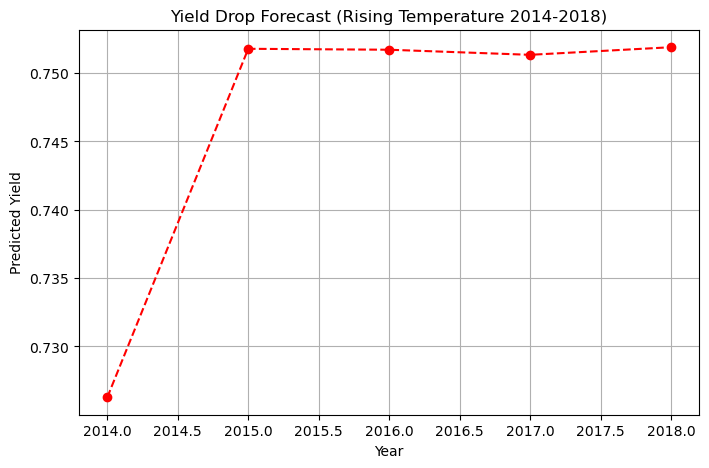

In [45]:
# Naya Scenario: Temperature har saal 0.5 degree badh raha hai
future_years = [2014, 2015, 2016, 2017, 2018]
base_temp = 25.0
projections = []

for i, year in enumerate(future_years):
    # Har saal temp .5 badhega: 25, 25.5, 26, 26.5, 27
    yearly_temp = base_temp + (i * 0.5) 
    
    # Input: Area, Item, Year, Rainfall, Pesticides, Yearly_Temp
    scenario = [[10, 5, year, 1000, 200000, yearly_temp]]
    prediction = model.predict(scenario)
    projections.append(prediction[0])
    print(f"Year {year} (Temp {yearly_temp}°C): Prediction {prediction[0]:.4f}")

# Ab graph plot karo
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(future_years, projections, marker='o', color='red', linestyle='dashed')
plt.title("Yield Drop Forecast (Rising Temperature 2014-2018)")
plt.xlabel("Year")
plt.ylabel("Predicted Yield")
plt.grid(True)
plt.show()

C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\lvved\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


--- Scenario Results ---
Normal Yield: 0.7263 hg/ha
Worst Case (High Temp + Low Rain): 0.7677 hg/ha
Optimized Case (High Temp + Better Management): 1.6814 hg/ha


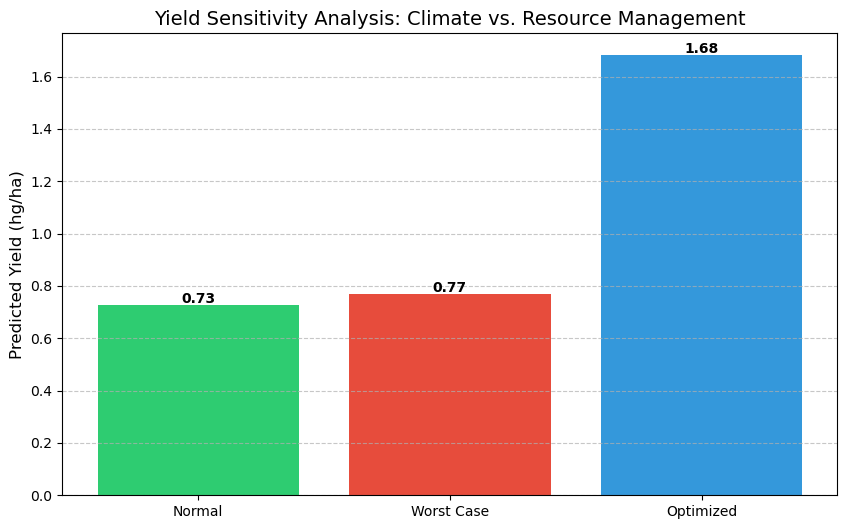

In [47]:
import matplotlib.pyplot as plt

# Base Scenario (Sab kuch normal - 2014)
# Format= [Area, Item, Year, Rainfall, Pesticides, Temp]
base_input = [[10, 5, 2014, 1000, 200000, 25]] 

# 2. Worst Case (Climate Crisis)
# Temperature high (30°C), Rainfall low (400mm), Pesticides low (100,000)
worst_case = [[10, 5, 2014, 400, 100000, 30]] 

# 3. Optimized Case (Management Impact)
# Temperature high hai (30°C), lekin humne Rainfall (1500mm) 
# aur Pesticides (400,000) badha diye compensatory factors ki tarah
optimized_case = [[10, 5, 2014, 1500, 400000, 30]] 

# Model se Predictions mangna
pred_base = model.predict(base_input)[0]
pred_worst = model.predict(worst_case)[0]
pred_opt = model.predict(optimized_case)[0]

# Results Print karna
print(f"--- Scenario Results ---")
print(f"Normal Yield: {pred_base:.4f} hg/ha")
print(f"Worst Case (High Temp + Low Rain): {pred_worst:.4f} hg/ha")
print(f"Optimized Case (High Temp + Better Management): {pred_opt:.4f} hg/ha")

# --- Visualization for Dashboard Page 2 ---
scenarios = ['Normal', 'Worst Case', 'Optimized']
yields = [pred_base, pred_worst, pred_opt]

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c', '#3498db'] # Green, Red, Blue
plt.bar(scenarios, yields, color=colors)

plt.title("Yield Sensitivity Analysis: Climate vs. Resource Management", fontsize=14)
plt.ylabel("Predicted Yield (hg/ha)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Values display karne ke liye bar ke upar
for i, v in enumerate(yields):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

In [51]:
# Predictions ko test data ke saath merge karna
ml_results = X_test.copy()
ml_results['Actual_Yield'] = y_test
ml_results['Predicted_Yield'] = y_pred

# Codes to names for dashboard
ml_results['Area'] = le_area.inverse_transform(ml_results['Area_Encoded'])
ml_results['Item'] = le_item.inverse_transform(ml_results['Item_Encoded'])
ml_results.to_csv('Global_Yield_Predictions.csv', index=False)


In [53]:
all_predictions = model.predict(X) 
overall_accuracy = r2_score(y, all_predictions)
print(f"Overall Accuracy on all 24,000 rows: {overall_accuracy * 100:.2f}%")

Overall Accuracy on all 24,000 rows: 99.31%


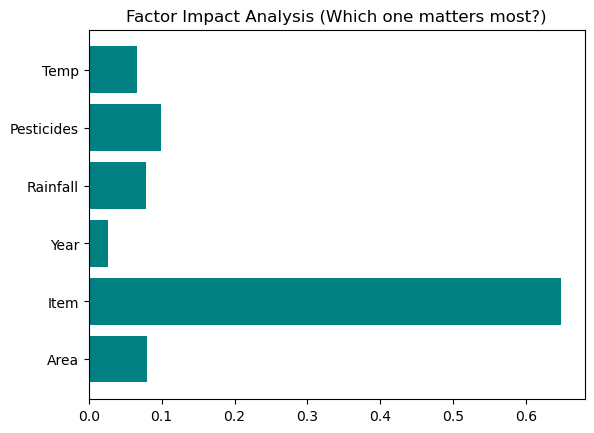

In [55]:
# Feature Importance check
importances = model.feature_importances_
features = ['Area', 'Item', 'Year', 'Rainfall', 'Pesticides', 'Temp']

plt.barh(features, importances, color='teal')
plt.title("Factor Impact Analysis (Which one matters most?)")
plt.show()